# 01 — Data Exploration

Explore the raw fashion products dataset before building the recommender.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/fashion_products.csv")
df.head()

,User ID,Product ID,Product Name,Brand,Category,Price,Rating,Color,Size
0,19,1,Dress,Adidas,Men's Fashion,40,1.043159,Black,XL
1,97,2,Shoes,H&M,Women's Fashion,82,4.026416,Black,L
2,25,3,Dress,Adidas,Women's Fashion,44,3.337938,Yellow,XL
3,57,4,Shoes,Zara,Men's Fashion,23,1.049523,White,S
4,79,5,T-shirt,Adidas,Men's Fashion,79,4.302773,Black,M


## Shape, dtypes, missing values

In [2]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Shape: (1000, 9)

User ID           int64
Product ID        int64
Product Name     object
Brand            object
Category         object
Price             int64
Rating          float64
Color            object
Size             object
dtype: object

Missing values per column:
User ID         0
Product ID      0
Product Name    0
Brand           0
Category        0
Price           0
Rating          0
Color           0
Size            0
dtype: int64

Duplicate rows: 0


## Categorical attribute cardinality

The dataset has no free-text description field — recommendations will be built from these structured attributes instead.

In [3]:
for col in ["Product Name", "Brand", "Category", "Color", "Size"]:
    print(col, "->", df[col].nunique(), "unique values:", sorted(df[col].unique()))

Product Name -> 5 unique values: ['Dress', 'Jeans', 'Shoes', 'Sweater', 'T-shirt']
Brand -> 5 unique values: ['Adidas', 'Gucci', 'H&M', 'Nike', 'Zara']
Category -> 3 unique values: ["Kids' Fashion", "Men's Fashion", "Women's Fashion"]
Color -> 6 unique values: ['Black', 'Blue', 'Green', 'Red', 'White', 'Yellow']
Size -> 4 unique values: ['L', 'M', 'S', 'XL']


## Distributions

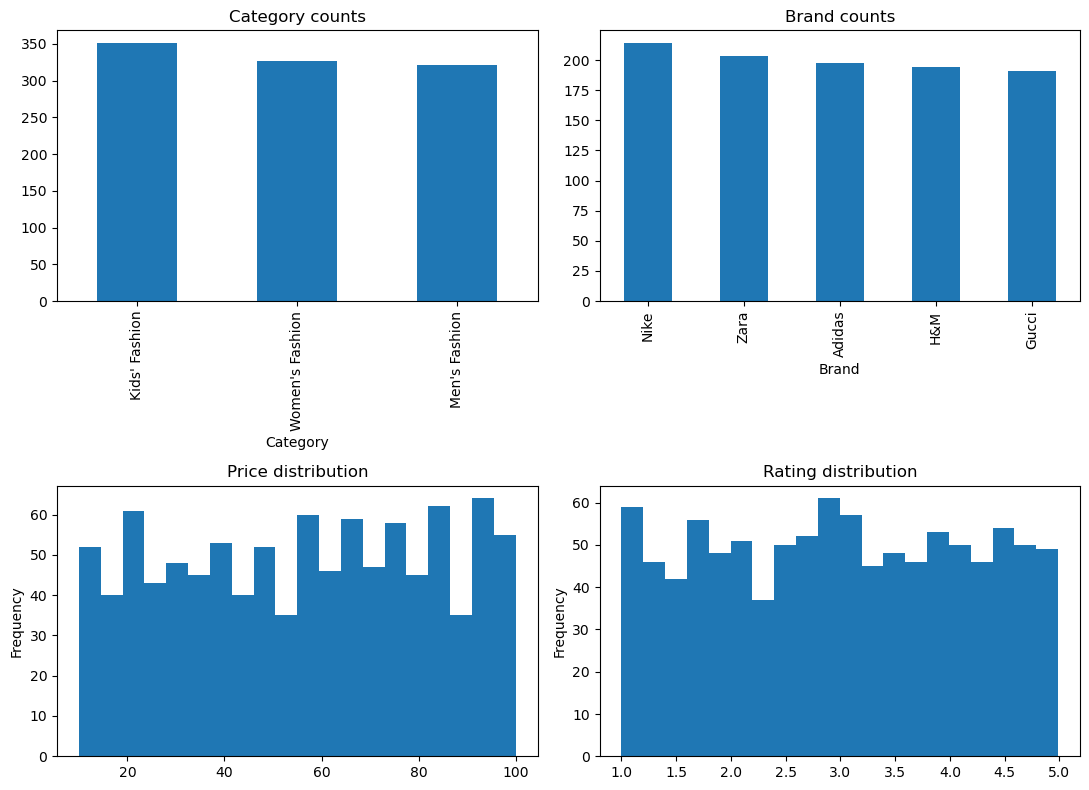

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

df["Category"].value_counts().plot(kind="bar", ax=axes[0, 0], title="Category counts")
df["Brand"].value_counts().plot(kind="bar", ax=axes[0, 1], title="Brand counts")
df["Price"].plot(kind="hist", bins=20, ax=axes[1, 0], title="Price distribution")
df["Rating"].plot(kind="hist", bins=20, ax=axes[1, 1], title="Rating distribution")

plt.tight_layout()
plt.show()

In [5]:
df.groupby("Category")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Category,,,,,,,,
Kids' Fashion,351.0,56.512821,26.064518,10.0,34.00,59.0,78.00,100.0
Men's Fashion,322.0,53.670807,26.299563,10.0,31.25,51.5,75.75,100.0
Women's Fashion,327.0,57.085627,26.479857,10.0,33.00,58.0,80.00,99.0


## Takeaways

- 1000 rows, no missing values, no duplicates.
- Only 5 product names, 5 brands, 3 categories, 6 colors, 4 sizes — low cardinality categorical data, no free text.
- Price and Rating are the only continuous numeric signals.
- This motivates building a synthesized "content profile" string from the categorical columns for TF-IDF, blended with scaled Price/Rating — see `02_preprocessing.ipynb`.